This is the notebook to visualize results of the plots. Please select `num_robots` from 2-5 and `exp_name` to either `default` or `random` to view the corresponding results in our paper.

In [92]:
# Select number of robot and exp_name to visualize the results in the paper
num_robots = 2 # Valid options: 2,3,4,5
exp_name = 'default' # Valid options: default, random

In [93]:
import os
import numpy as np
import glob
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

In [94]:
# Gather data
data = []
log_path = os.path.join('..', f'training_{exp_name}_logs', f'{num_robots}_robots', 'logs', '*', '*') # Set the path for the experiments
logs = glob.glob(log_path)
for log in logs:
    if "events.out.tfevents" in log:
        experiment_info = log.split(os.sep)[-2].split('_')
        algorithm = experiment_info[0]
        st = experiment_info[1]
        # print(log)
        print(log.split(os.sep))
        print(experiment_info)
        
        for e in tf.compat.v1.train.summary_iterator(log):
            for v in e.summary.value:
                if v.tag == 'rollout/ep_rew_mean':
                    data.append({
                        'algorithm': algorithm,
                        'set': st,
                        'step': e.step,
                        'reward': v.simple_value
                    })
    else:
        print(f"Not a tensorflow log file, file: {log}")
df = pd.DataFrame(data)
# df.to_csv(rf"results\wheeled_default_raw_{date}.csv")
df

['..', 'training_default_logs', '2_robots', 'logs', 'A2C_set1', 'events.out.tfevents.1769551912.hero17.64699.0']
['A2C', 'set1']
Not a tensorflow log file, file: ..\training_default_logs\2_robots\logs\A2C_set1\log.txt
Not a tensorflow log file, file: ..\training_default_logs\2_robots\logs\A2C_set1\progress.csv
Not a tensorflow log file, file: ..\training_default_logs\2_robots\logs\A2C_set1\progress.json
['..', 'training_default_logs', '2_robots', 'logs', 'A2C_set10', 'events.out.tfevents.1769551918.mole047.3842786.0']
['A2C', 'set10']
Not a tensorflow log file, file: ..\training_default_logs\2_robots\logs\A2C_set10\log.txt
Not a tensorflow log file, file: ..\training_default_logs\2_robots\logs\A2C_set10\progress.csv
Not a tensorflow log file, file: ..\training_default_logs\2_robots\logs\A2C_set10\progress.json
['..', 'training_default_logs', '2_robots', 'logs', 'A2C_set2', 'events.out.tfevents.1769551939.hero53.61177.0']
['A2C', 'set2']
Not a tensorflow log file, file: ..\training_defa

,algorithm,set,step,reward
0,A2C,set1,10000,-264377.468750
1,A2C,set1,20000,-156677.593750
2,A2C,set1,30000,-143916.828125
3,A2C,set1,40000,-130292.484375
4,A2C,set1,50000,-124826.445312
...,...,...,...,...
6033,TRPO,set9,960000,48636.902344
6034,TRPO,set9,970000,52330.031250
6035,TRPO,set9,980000,58464.449219
6036,TRPO,set9,990000,63018.179688


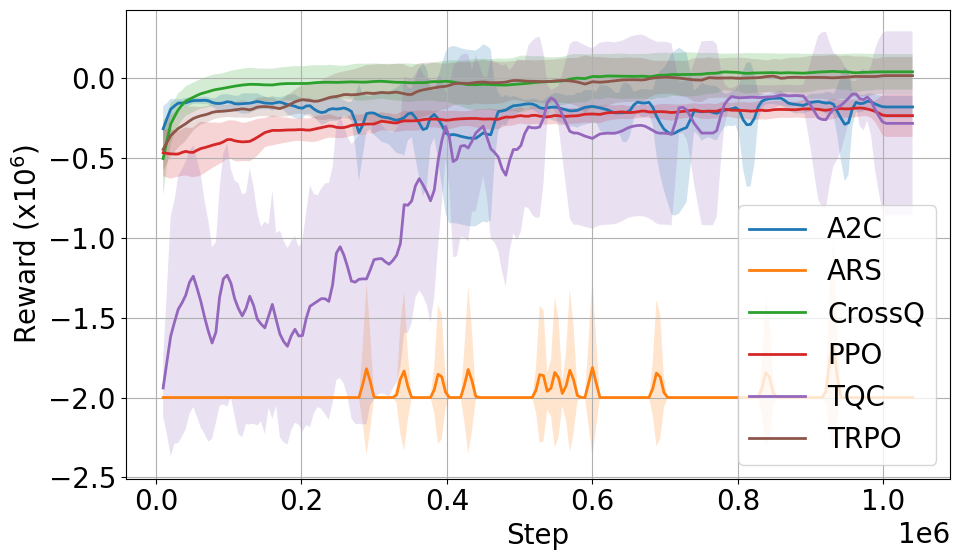

In [95]:
# Scaling the rewards for visualization
df['reward_scaled'] = df['reward'] / 1000000
df['reward_scaled'] = df['reward_scaled'].clip(lower=-2)

# Define a common x-axis (based on min-max steps across all algorithms)
min_step = df['step'].min()
max_step = df['step'].max()
common_steps = np.linspace(min_step, max_step, 200)

plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(10,6))

# Group by algorithm
for algo, algo_df in df.groupby('algorithm'):
    runs = []

    # For each run (set), interpolate rewards to common steps
    for run_id, run_df in algo_df.groupby('set'):
        x = run_df['step'].values
        y = run_df['reward_scaled'].values
        interp_rewards = np.interp(common_steps, x, y)
        runs.append(interp_rewards)

    runs = np.array(runs)
    mean_rewards = runs.mean(axis=0)
    std_rewards = runs.std(axis=0)

    # Plot with variance shading
    plt.plot(common_steps, mean_rewards, label=algo, linewidth=2)
    plt.fill_between(common_steps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)

plt.xlabel("Step")
plt.ylabel("Reward (x$10^6$)")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig(rf"plots/{exp_name}_graph_for_{num_robots}_robots.png")
plt.show()

In [96]:
A2C_df = df[df['algorithm']=='A2C']
ARS_df = df[df['algorithm']=='ARS']
CrossQ_df = df[df['algorithm']=='CrossQ']
PPO_df = df[df['algorithm']=='PPO']
TQC_df = df[df['algorithm']=='TQC']
TRPO_df = df[df['algorithm']=='TRPO']


A2C_data = {"Setting": "AB", 
            "Algorithm": "A2C", 
            "Mean": A2C_df['reward'].mean(),
            "Max": A2C_df['reward'].max(),
            "SD": A2C_df['reward'].std(),
            "Range": (A2C_df['reward'].max() - A2C_df['reward'].min())}
ARS_data = {"Setting": "AB", 
            "Algorithm": "ARS", 
            "Mean": ARS_df['reward'].mean(),            
            "Max": ARS_df['reward'].max(),
            "SD": ARS_df['reward'].std(),
            "Range": (ARS_df['reward'].max() - ARS_df['reward'].min())}
CrossQ_data = {"Setting": "AB", 
            "Algorithm": "CrossQ", 
            "Mean": CrossQ_df['reward'].mean(),            
            "Max": CrossQ_df['reward'].max(),
            "SD": CrossQ_df['reward'].std(),
            "Range": (CrossQ_df['reward'].max() - CrossQ_df['reward'].min())}
PPO_data = {"Setting": "AB", 
            "Algorithm": "PPO", 
            "Mean": PPO_df['reward'].mean(),
            "Max": PPO_df['reward'].max(),
            "SD": PPO_df['reward'].std(),            
            "Range": (PPO_df['reward'].max() - PPO_df['reward'].min())}
TQC_data = {"Setting": "AB", 
            "Algorithm": "TQC", 
            "Mean": TQC_df['reward'].mean(),            
            "Max": TQC_df['reward'].max(),
            "SD": TQC_df['reward'].std(),
            "Range": (TQC_df['reward'].max() - TQC_df['reward'].min())}
TRPO_data = {"Setting": "AB", 
            "Algorithm": "TRPO", 
            "Mean": TRPO_df['reward'].mean(),            
            "Max": TRPO_df['reward'].max(),
            "SD": TRPO_df['reward'].std(),
            "Range": (TRPO_df['reward'].max() - TRPO_df['reward'].min())}


set_tab_df = pd.DataFrame([A2C_data, ARS_data, CrossQ_data, PPO_data, TQC_data, TRPO_data])
set_tab_df

,Setting,Algorithm,Mean,Max,SD,Range
0,AB,A2C,-2.295153e+05,36341.132812,4.718387e+05,7.928587e+06
1,AB,ARS,-1.695634e+07,-94890.179688,3.494260e+06,2.002653e+07
2,AB,CrossQ,-1.776936e+04,133794.390625,1.465105e+05,1.003652e+06
3,AB,PPO,-2.652016e+05,-86358.601562,1.081225e+05,7.061400e+05
4,AB,TQC,-2.138898e+06,-25962.244141,3.753259e+06,1.940191e+07
5,AB,TRPO,-6.793439e+04,133432.234375,1.587257e+05,7.805358e+05


In [97]:
set_tab_df_sc = set_tab_df.select_dtypes(include='number') / 1000000
set_tab_df_sc.insert(0, 'Setting', set_tab_df['Setting'])
set_tab_df_sc.insert(1, 'Algorithm', set_tab_df['Algorithm'])
set_tab_df_sc

,Setting,Algorithm,Mean,Max,SD,Range
0,AB,A2C,-0.229515,0.036341,0.471839,7.928587
1,AB,ARS,-16.956339,-0.094890,3.494260,20.026526
2,AB,CrossQ,-0.017769,0.133794,0.146511,1.003652
3,AB,PPO,-0.265202,-0.086359,0.108123,0.706140
4,AB,TQC,-2.138898,-0.025962,3.753259,19.401908
5,AB,TRPO,-0.067934,0.133432,0.158726,0.780536


In [98]:
set_tab_df_sc_trans = set_tab_df_sc.T
set_tab_df_sc_trans.to_csv(f'results/{exp_name}_results_for_{num_robots}_robots.csv')
set_tab_df_sc_trans

,0,1,2,3,4,5
Setting,AB,AB,AB,AB,AB,AB
Algorithm,A2C,ARS,CrossQ,PPO,TQC,TRPO
Mean,-0.229515,-16.956339,-0.017769,-0.265202,-2.138898,-0.067934
Max,0.036341,-0.09489,0.133794,-0.086359,-0.025962,0.133432
SD,0.471839,3.49426,0.146511,0.108123,3.753259,0.158726
Range,7.928587,20.026526,1.003652,0.70614,19.401908,0.780536
